First version of a working network for test

- Why is there exactly the same value of stddev for each image and each tests?? (in e1, e2 and z) : because of the 'relu' activation in last dense layer. It prevented covariance matrice to have negative terms and consequently the learning of covariance was limited. This is now modified.

In [1]:
import tensorflow_probability as tfp
import tensorflow as tf

from tensorflow.keras import backend as K

import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

from importlib import reload

In [2]:
import sys
import os
sys.path.insert(0,'../../scripts/tools_for_VAE/')
import tools_for_VAE.layers as layers
from tools_for_VAE import utils, vae_functions, generator, model

W0615 14:45:19.431883 139928716011328 deprecation.py:323] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/compat/v2_compat.py:65: disable_resource_variables (from tensorflow.python.ops.variable_scope) is deprecated and will be removed in a future version.
Instructions for updating:
non-resource variables are not supported in the long term


In [3]:
reload(utils)

<module 'tools_for_VAE.utils' from '../../scripts/tools_for_VAE/tools_for_VAE/utils.py'>

In [4]:
from tensorflow.keras.layers import Input, Dense, Lambda, Layer, Add, Multiply, Reshape, Flatten, BatchNormalization
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Conv2D, Input, Dense, Dropout, MaxPool2D, Flatten,  Reshape, UpSampling2D, Cropping2D, Conv2DTranspose, PReLU, Concatenate, Lambda, BatchNormalization, concatenate, LeakyReLU

In [5]:
tfd = tfp.distributions

In [6]:
import tensorflow

# Parameters

In [133]:
nb_of_bands = 6
batch_size = 100 

input_shape = (64, 64, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 3
filters = [32, 64, 128, 256]#, 512]
kernels = [3,3,3,3]#, 3]

conv_activation = None
dense_activation = None

bands = [4,5,6,7,8,9]

# Data loading

## Batchgenerator

In [52]:
images_dir = '/sps/lsst/users/barcelin/data/TFP/GalSim_COSMOS/isolated_galaxies/centered/'
list_of_samples = [x for x in utils.listdir_fullpath(os.path.join(images_dir,'test')) if x.endswith('.npy')]
list_of_samples_val = [x for x in utils.listdir_fullpath(os.path.join(images_dir,'validation')) if x.endswith('.npy')]

In [53]:
test_generator = generator.BatchGenerator(bands, list_of_samples, total_sample_size=None,
                                    batch_size=batch_size, 
                                    trainval_or_test='training',
                                    do_norm=False,
                                    denorm = False,
                                    list_of_weights_e=None)


[BatchGenerator] total_sample_size =  10000
[BatchGenerator] len(list_of_samples) =  1


# Model with latent space

## Model architecture

In [121]:
net = model.create_model(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

In [122]:
net.summary()

Model: "model_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_5 (InputLayer)         [(None, 64, 64, 6)]       0         
_________________________________________________________________
batch_normalization_4 (Batch (None, 64, 64, 6)         24        
_________________________________________________________________
conv2d_10 (Conv2D)           (None, 64, 64, 32)        1760      
_________________________________________________________________
p_re_lu_38 (PReLU)           (None, 64, 64, 32)        131072    
_________________________________________________________________
conv2d_11 (Conv2D)           (None, 32, 32, 32)        9248      
_________________________________________________________________
p_re_lu_39 (PReLU)           (None, 32, 32, 32)        32768     
_________________________________________________________________
conv2d_12 (Conv2D)           (None, 32, 32, 64)        1849

In [123]:
loading_path = '/sps/lsst/users/barcelin/TFP/weights/test_2/'

latest = tf.train.latest_checkpoint(loading_path)
net.load_weights(latest)

## Test

In [13]:
n = 10

In [14]:
test_data = np.zeros((n*batch_size, 64, 64, 6))
test_labels = np.zeros((n*batch_size, 3))

for i in range (n):
    test = test_generator.__getitem__(2)
    test_data[i*batch_size: (i+1)*batch_size] = test[0]
    test_labels[i*batch_size: (i+1)*batch_size] = test[1]

In [30]:
test_data.shape

(1000, 64, 64, 6)

In [31]:
out = net(test_data)

In [32]:
# Compute ellipticities in [0,1], inverse function of the one in the generator
out_mean = np.zeros((n*batch_size,3))

out_mean[:,0] = out.mean().numpy()[:,0]#np.log(out.mean().numpy()[:,0]/2)
out_mean[:,1] = out.mean().numpy()[:,1]#np.log(out.mean().numpy()[:,1]/2)
out_mean[:,2] = out.mean().numpy()[:,2]
                    
                    
out_stddev = np.zeros((n*batch_size,3))

out_stddev[:,0] = out.stddev().numpy()[:,0]#np.log(out.stddev().numpy()[:,0]/2)
out_stddev[:,1] = out.stddev().numpy()[:,1]#np.log(out.stddev().numpy()[:,1]/2)
out_stddev[:,2] = out.stddev().numpy()[:,2]

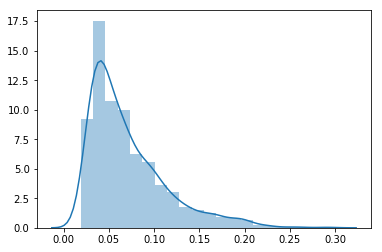

In [33]:
sns.distplot(out_stddev[:,0], bins = 20)

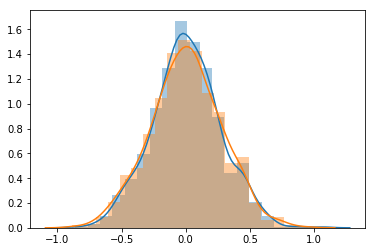

In [34]:
sns.distplot(out_mean[:,0], bins = 20)
sns.distplot(test_labels[:, 0], bins = 20)

### One sampling for 1000 images (ten batch)

Text(0.5, 1.0, '$z$')

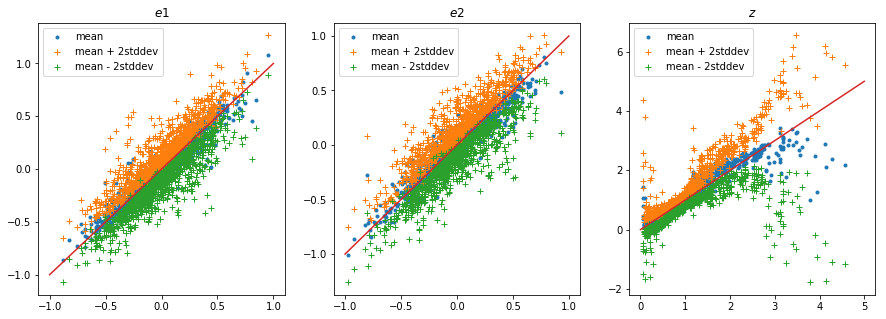

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(test_labels[:, 0], out_mean[:,0], '.', label = 'mean')
axes[0].plot(test_labels[:, 0], out_mean[:,0]+ 2*out_stddev[:,0], '+', label = 'mean + 2stddev')
axes[0].plot(test_labels[:, 0], out_mean[:,0]- 2*out_stddev[:,0], '+', label = 'mean - 2stddev')
x = np.linspace(-1,1)
axes[0].plot(x, x)
axes[0].legend()
#axes[0].set_ylim(-0.5,6.5)
axes[0].set_title('$e1$')

axes[1].plot(test_labels[:, 1], out_mean[:,1], '.', label = 'mean')
axes[1].plot(test_labels[:, 1], out_mean[:,1]+ 2*out_stddev[:,1], '+', label = 'mean + 2stddev')
axes[1].plot(test_labels[:, 1], out_mean[:,1]- 2*out_stddev[:,1], '+', label = 'mean - 2stddev')
x = np.linspace(-1,1)
axes[1].plot(x, x)
axes[1].legend()
#axes[1].set_ylim(-0.5,6.5)
axes[1].set_title('$e2$')

axes[2].plot(test_labels[:,2], out_mean[:,2], '.', label = 'mean')
axes[2].plot(test_labels[:,2], out_mean[:,2]+ 2*out_stddev[:,2], '+', label = 'mean + 2stddev')
axes[2].plot(test_labels[:,2], out_mean[:,2]- 2*out_stddev[:,2], '+', label = 'mean - 2stddev')
x = np.linspace(0,5)
axes[2].plot(x, x)
axes[2].legend()
#axes[2].set_ylim(-1,5.5)
axes[2].set_title('$z$')

### N samplings for 100 images (one batch)

In [36]:
N = 100
means_e1 = np.zeros((N,100))
stddevs_e1 = np.zeros((N,100))
means_e2 = np.zeros((N,100))
stddevs_e2 = np.zeros((N,100))
means_z = np.zeros((N,100))
stddevs_z = np.zeros((N,100))

outs = np.zeros((N,100))
for i in range (N):
    out = net(test_data[:100])
    outs[i] = out[:,0].numpy()
    means_e1[i] = out.mean().numpy()[:,0]
    stddevs_e1[i] = out.stddev().numpy()[:,0]
    means_e2[i] = out.mean().numpy()[:,1]
    stddevs_e2[i] = out.stddev().numpy()[:,1]
    means_z[i] = out.mean().numpy()[:,2]
    stddevs_z[i] = out.stddev().numpy()[:,2]

#### E1

In [52]:
image_nb = 0

0.10704660415649414


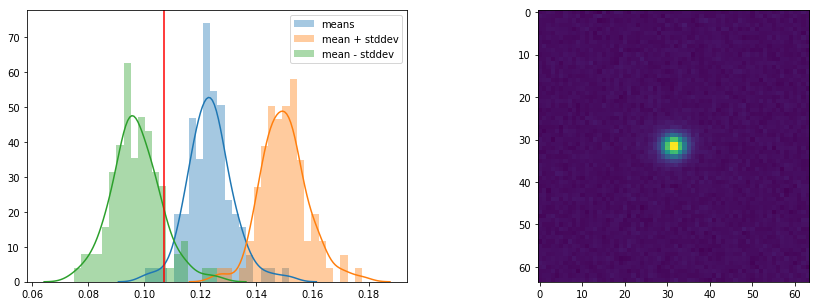

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.distplot(means_e1[:,image_nb], bins = 20, label = 'means', ax = axes[0])
sns.distplot(means_e1[:,image_nb] + stddevs_e1[:,image_nb], bins = 20, label = 'mean + stddev', ax = axes[0])
sns.distplot(means_e1[:,image_nb] - stddevs_e1[:,image_nb], bins = 20, label = 'mean - stddev', ax = axes[0])
axes[0].axvline(test_labels[image_nb,0], color = 'r')
axes[0].legend()
print(test_labels[image_nb,0])

axes[1].imshow(test_data[image_nb,:,:,2])

#### E2

0.006916262675076722


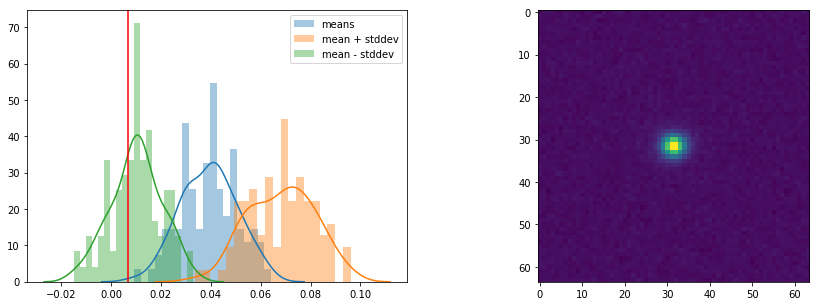

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.distplot(means_e2[:,image_nb], bins = 20, label = 'means', ax = axes[0])
sns.distplot(means_e2[:,image_nb] + stddevs_e2[:,image_nb], bins = 20, label = 'mean + stddev', ax = axes[0])
sns.distplot(means_e2[:,image_nb] - stddevs_e2[:,image_nb], bins = 20, label = 'mean - stddev', ax = axes[0])
axes[0].axvline(test_labels[image_nb,1], color = 'r')
axes[0].legend()
print(test_labels[image_nb,1])

axes[1].imshow(test_data[image_nb,:,:,2])

#### Redshift

0.7778000235557556


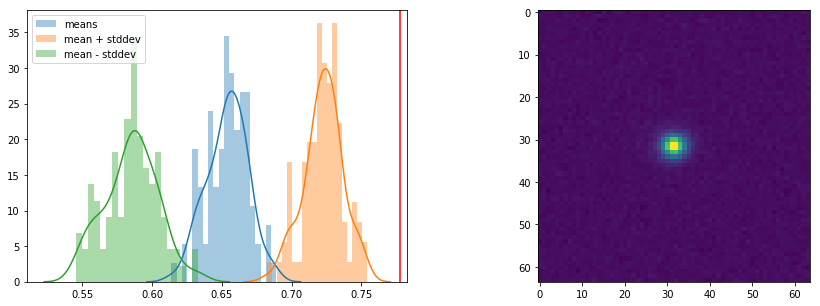

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.distplot(means_z[:,image_nb], bins = 20, label = 'means', ax = axes[0])
sns.distplot(means_z[:,image_nb] + stddevs_z[:,image_nb], bins = 20, label = 'mean + stddev', ax = axes[0])
sns.distplot(means_z[:,image_nb] - stddevs_z[:,image_nb], bins = 20, label = 'mean - stddev', ax = axes[0])
axes[0].axvline(test_labels[image_nb,2], color = 'r')
axes[0].legend()
print(test_labels[image_nb,2])

axes[1].imshow(test_data[image_nb,:,:,2])

#### Distributions

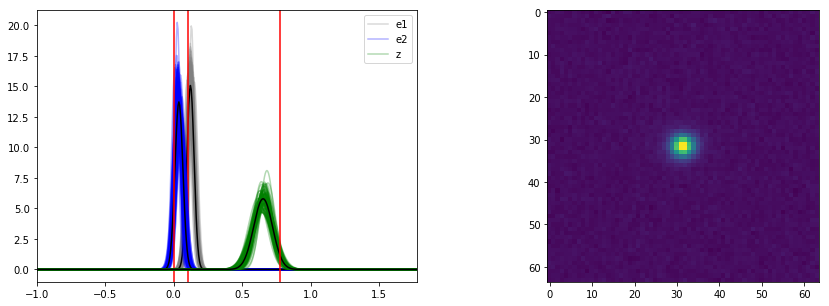

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.linspace(-1,5, 1000)

for i in range (len(means_e1)):
    axes[0].plot(x, (1/(stddevs_e1[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[i,image_nb])/(2*stddevs_e1[i,image_nb]**2))), color = 'grey', alpha = 0.3)
    if i == len(means_e1)-1 : 
        axes[0].plot(x, (1/(stddevs_e1[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[i,image_nb])/(2*stddevs_e1[i,image_nb]**2))), color = 'grey', alpha = 0.3 , label = 'e1')
mean_means = np.mean(means_e1[:,image_nb])
mean_stddevs = np.mean(stddevs_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'black', alpha = 1)    
axes[0].axvline(test_labels[image_nb,0], color = 'r')

for i in range (len(means_e1)):
    axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.3)
    if i == len(means_e1)-1:
        axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.3, label= 'e2')
mean_means = np.mean(means_e2[:,image_nb])
mean_stddevs = np.mean(stddevs_e2[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'black', alpha = 1)    
axes[0].axvline(test_labels[image_nb,1], color = 'r')

for i in range (len(means_e1)):
    axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.3)
    if i == len(means_e1)-1:
        axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.3, label = 'z')
mean_means = np.mean(means_z[:,image_nb])
mean_stddevs = np.mean(stddevs_z[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'black', alpha = 1)    
axes[0].axvline(test_labels[image_nb,2], color = 'r')
axes[0].set_xlim(-1,test_labels[image_nb,2]+1)

axes[1].imshow(test_data[image_nb,:,:,2])
axes[0].legend()


### Other example

In [43]:
image_nb = 1

0.01636376418173313


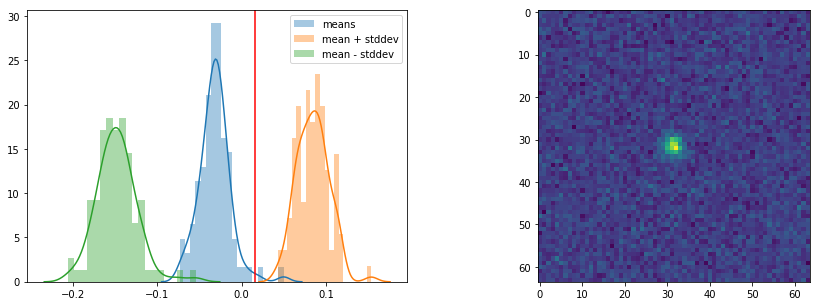

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.distplot(means_e1[:,image_nb], bins = 20, label = 'means', ax = axes[0])
sns.distplot(means_e1[:,image_nb] + stddevs_e1[:,image_nb], bins = 20, label = 'mean + stddev', ax = axes[0])
sns.distplot(means_e1[:,image_nb] - stddevs_e1[:,image_nb], bins = 20, label = 'mean - stddev', ax = axes[0])
axes[0].axvline(test_labels[image_nb,0], color = 'r')
axes[0].legend()
print(test_labels[image_nb,0])

axes[1].imshow(test_data[image_nb,:,:,2])

0.3566828668117523


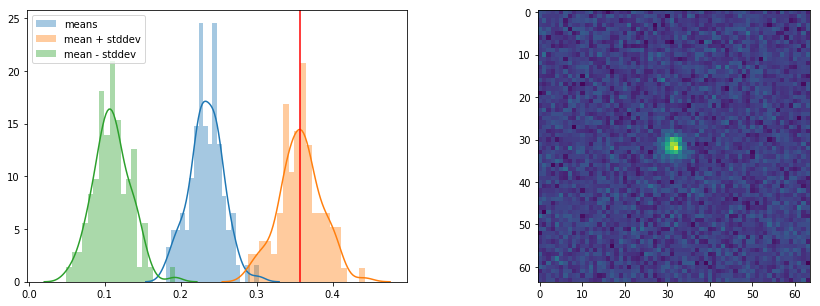

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.distplot(means_e2[:,image_nb], bins = 20, label = 'means', ax = axes[0])
sns.distplot(means_e2[:,image_nb] + stddevs_e2[:,image_nb], bins = 20, label = 'mean + stddev', ax = axes[0])
sns.distplot(means_e2[:,image_nb] - stddevs_e2[:,image_nb], bins = 20, label = 'mean - stddev', ax = axes[0])
axes[0].axvline(test_labels[image_nb,1], color = 'r')
axes[0].legend()
print(test_labels[image_nb,1])

axes[1].imshow(test_data[image_nb,:,:,2])

0.5582000017166138


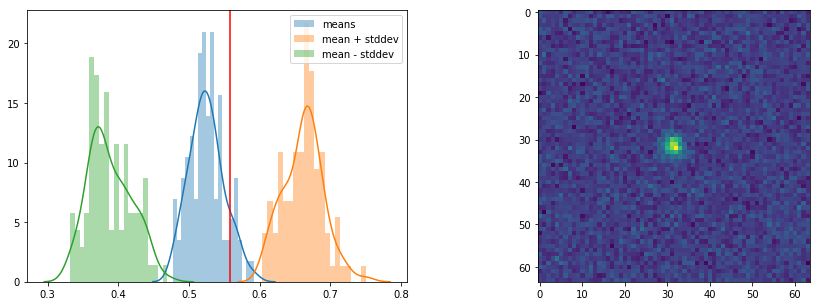

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.distplot(means_z[:,image_nb], bins = 20, label = 'means', ax = axes[0])
sns.distplot(means_z[:,image_nb] + stddevs_z[:,image_nb], bins = 20, label = 'mean + stddev', ax = axes[0])
sns.distplot(means_z[:,image_nb] - stddevs_z[:,image_nb], bins = 20, label = 'mean - stddev', ax = axes[0])
axes[0].axvline(test_labels[image_nb,2], color = 'r')
axes[0].legend()
print(test_labels[image_nb,2])

axes[1].imshow(test_data[image_nb,:,:,2])

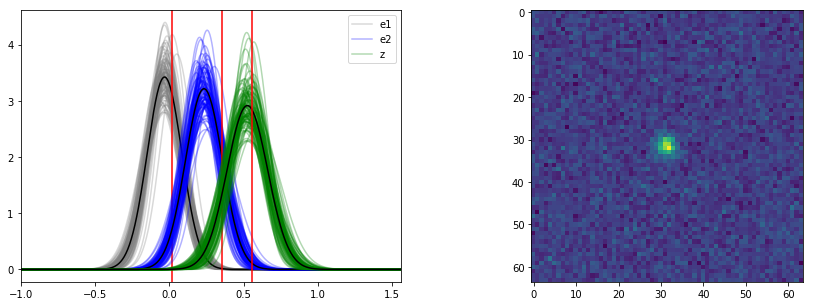

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.linspace(-1,5, 1000)

for i in range (len(means_e1)):
    axes[0].plot(x, (1/(stddevs_e1[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[i,image_nb])/(2*stddevs_e1[i,image_nb]**2))), color = 'grey', alpha = 0.3)
    if i == len(means_e1)-1 : 
        axes[0].plot(x, (1/(stddevs_e1[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[i,image_nb])/(2*stddevs_e1[i,image_nb]**2))), color = 'grey', alpha = 0.3 , label = 'e1')
mean_means = np.mean(means_e1[:,image_nb])
mean_stddevs = np.mean(stddevs_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'black', alpha = 1)    
axes[0].axvline(test_labels[image_nb,0], color = 'r')

for i in range (len(means_e1)):
    axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.3)
    if i == len(means_e1)-1:
        axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.3, label= 'e2')
mean_means = np.mean(means_e2[:,image_nb])
mean_stddevs = np.mean(stddevs_e2[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'black', alpha = 1)    
axes[0].axvline(test_labels[image_nb,1], color = 'r')

for i in range (len(means_e1)):
    axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.3)
    if i == len(means_e1)-1:
        axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.3, label = 'z')
mean_means = np.mean(means_z[:,image_nb])
mean_stddevs = np.mean(stddevs_z[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'black', alpha = 1)    
axes[0].axvline(test_labels[image_nb,2], color = 'r')
axes[0].set_xlim(-1,test_labels[image_nb,2]+1)

axes[1].imshow(test_data[image_nb,:,:,2])
axes[0].legend()


# Model without latent space

## Model architecture

In [24]:
reload(model)

<module 'tools_for_VAE.model' from '../../scripts/tools_for_VAE/tools_for_VAE/model.py'>

In [124]:
net_wo_ls = model.create_model_wo_ls(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

In [125]:
net_wo_ls.summary()

Model: "model_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_6 (InputLayer)         [(None, 64, 64, 6)]       0         
_________________________________________________________________
batch_normalization_5 (Batch (None, 64, 64, 6)         24        
_________________________________________________________________
conv2d_20 (Conv2D)           (None, 64, 64, 32)        1760      
_________________________________________________________________
p_re_lu_49 (PReLU)           (None, 64, 64, 32)        131072    
_________________________________________________________________
conv2d_21 (Conv2D)           (None, 32, 32, 32)        9248      
_________________________________________________________________
p_re_lu_50 (PReLU)           (None, 32, 32, 32)        32768     
_________________________________________________________________
conv2d_22 (Conv2D)           (None, 32, 32, 64)        1849

In [126]:
loading_path = '/sps/lsst/users/barcelin/TFP/weights/test_4/'

latest = tf.train.latest_checkpoint(loading_path)
net_wo_ls.load_weights(latest)

## Test

In [18]:
n = 10

In [19]:
test_data = np.zeros((n*batch_size, 64, 64, 6))
test_labels = np.zeros((n*batch_size, 3))

for i in range (n):
    test = test_generator.__getitem__(2)
    test_data[i*batch_size: (i+1)*batch_size] = test[0]
    test_labels[i*batch_size: (i+1)*batch_size] = test[1]

In [20]:
out = net_wo_ls(test_data)

W0415 11:20:41.843482 140494534559552 base_layer.py:1814] Layer batch_normalization_1 is casting an input tensor from dtype float64 to the layer's dtype of float32, which is new behavior in TensorFlow 2.  The layer has dtype float32 because it's dtype defaults to floatx.

If you intended to run this layer in float32, you can safely ignore this warning. If in doubt, this warning is likely only an issue if you are porting a TensorFlow 1.X model to TensorFlow 2.

To change all layers to have dtype float64 by default, call `tf.keras.backend.set_floatx('float64')`. To change just this layer, pass dtype='float64' to the layer constructor. If you are the author of this layer, you can disable autocasting by passing autocast=False to the base Layer constructor.



In [21]:
# Compute ellipticities in [0,1], inverse function of the one in the generator
out_mean = np.zeros((n*batch_size,3))

out_mean[:,0] = out.mean().numpy()[:,0]
out_mean[:,1] = out.mean().numpy()[:,1]
out_mean[:,2] = out.mean().numpy()[:,2]
                    
                    
out_stddev = np.zeros((n*batch_size,3))

out_stddev[:,0] = out.stddev().numpy()[:,0]
out_stddev[:,1] = out.stddev().numpy()[:,1]
out_stddev[:,2] = out.stddev().numpy()[:,2]

### One sampling for 1000 images (ten batch)

Text(0.5, 1.0, '$z$')

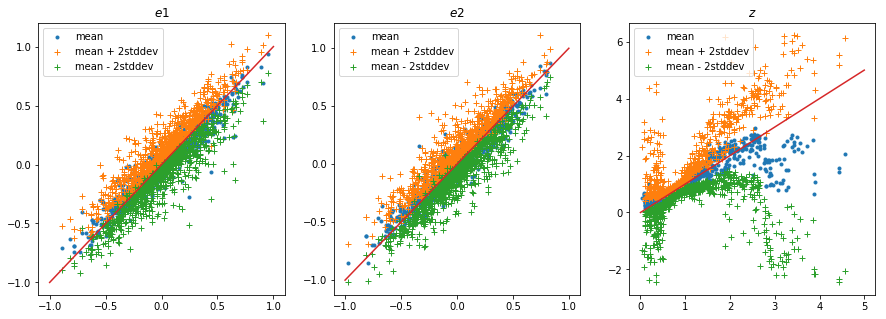

In [132]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(test_labels[:, 0], out_mean[:,0], '.', label = 'mean')
axes[0].plot(test_labels[:, 0], out_mean[:,0]+ 2*out_stddev[:,0], '+', label = 'mean + 2stddev')
axes[0].plot(test_labels[:, 0], out_mean[:,0]- 2*out_stddev[:,0], '+', label = 'mean - 2stddev')
x = np.linspace(-1,1)
axes[0].plot(x, x)
axes[0].legend()
#axes[0].set_ylim(-0.5,6.5)
axes[0].set_title('$e1$')

axes[1].plot(test_labels[:, 1], out_mean[:,1], '.', label = 'mean')
axes[1].plot(test_labels[:, 1], out_mean[:,1]+ 2*out_stddev[:,1], '+', label = 'mean + 2stddev')
axes[1].plot(test_labels[:, 1], out_mean[:,1]- 2*out_stddev[:,1], '+', label = 'mean - 2stddev')
x = np.linspace(-1,1)
axes[1].plot(x, x)
axes[1].legend()
#axes[1].set_ylim(-0.5,6.5)
axes[1].set_title('$e2$')

axes[2].plot(test_labels[:,2], out_mean[:,2], '.', label = 'mean')
axes[2].plot(test_labels[:,2], out_mean[:,2]+ 2*out_stddev[:,2], '+', label = 'mean + 2stddev')
axes[2].plot(test_labels[:,2], out_mean[:,2]- 2*out_stddev[:,2], '+', label = 'mean - 2stddev')
x = np.linspace(0,5)
axes[2].plot(x, x)
axes[2].legend()
#axes[2].set_ylim(-1,5.5)
axes[2].set_title('$z$')

### N samplings for 100 images (one batch)

In [24]:
N = 100
means_e1 = np.zeros((N,100))
stddevs_e1 = np.zeros((N,100))
means_e2 = np.zeros((N,100))
stddevs_e2 = np.zeros((N,100))
means_z = np.zeros((N,100))
stddevs_z = np.zeros((N,100))

outs = np.zeros((N,100))
for i in range (N):
    out = net_wo_ls(test_data[:100])
    outs[i] = out[:,0].numpy()
    means_e1[i] = out.mean().numpy()[:,0]
    stddevs_e1[i] = out.stddev().numpy()[:,0]
    means_e2[i] = out.mean().numpy()[:,1]
    stddevs_e2[i] = out.stddev().numpy()[:,1]
    means_z[i] = out.mean().numpy()[:,2]
    stddevs_z[i] = out.stddev().numpy()[:,2]

In [134]:
print(means_e1[:,1], stddevs_e1[:,1])

[-0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561
 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561
 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561
 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561
 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561
 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561
 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561
 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561
 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561
 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561
 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561
 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561
 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0.23407561
 -0.23407561 -0.23407561 -0.23407561 -0.23407561 -0

As expected, mean and stddev are the same for a galaxy passed 100 times in the network.

#### Distribution

In [22]:
image_nb = 0

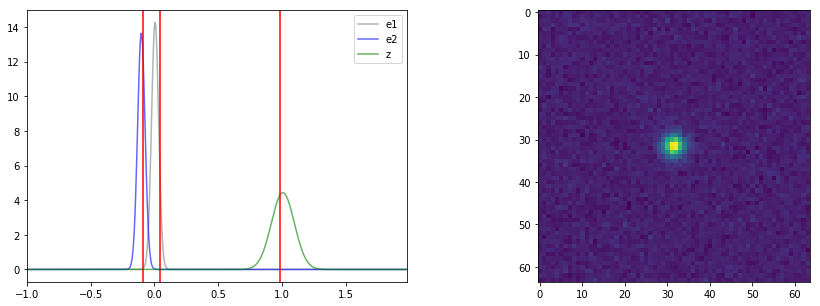

In [136]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.linspace(-1,5, 1000)


axes[0].plot(x, (1/(stddevs_e1[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[0,image_nb])/(2*stddevs_e1[0,image_nb]**2))), color = 'grey', alpha = 0.6, label = 'e1')
# mean_means = np.mean(means_e1[:,image_nb])
# mean_stddevs = np.mean(stddevs_e1[:,image_nb])
# axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'black', alpha = 1)    
axes[0].axvline(test_labels[image_nb,0], color = 'r')

axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.6, label= 'e2')
# mean_means = np.mean(means_e2[:,image_nb])
# mean_stddevs = np.mean(stddevs_e2[:,image_nb])
# axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'black', alpha = 1)    
axes[0].axvline(test_labels[image_nb,1], color = 'r')


axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.6, label= 'z')
#mean_means = np.mean(means_z[:,image_nb])
#mean_stddevs = np.mean(stddevs_z[:,image_nb])
#axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'black', alpha = 1)    
axes[0].axvline(test_labels[image_nb,2], color = 'r')
axes[0].set_xlim(-1,test_labels[image_nb,2]+1)

axes[1].imshow(test_data[image_nb,:,:,2])
axes[0].legend()

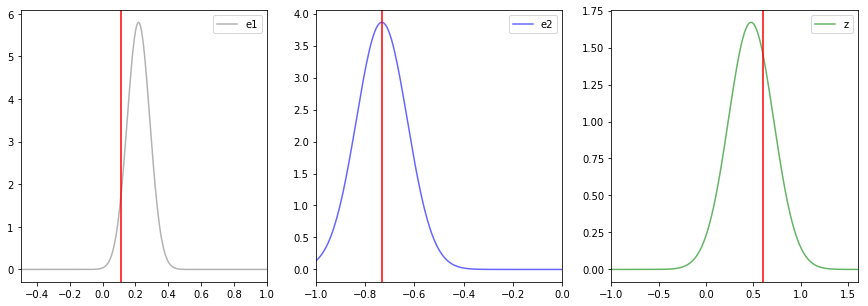

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x = np.linspace(-1,5, 1000)


axes[0].plot(x, (1/(stddevs_e1[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[0,image_nb])/(2*stddevs_e1[0,image_nb]**2))), color = 'grey', alpha = 0.6, label = 'e1')
axes[0].axvline(test_labels[image_nb,0], color = 'r')
axes[0].set_xlim(-0.5,1)

axes[1].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.6, label= 'e2')
axes[1].axvline(test_labels[image_nb,1], color = 'r')
axes[1].set_xlim(-1,0)

axes[2].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.6, label= 'z')
axes[2].axvline(test_labels[image_nb,2], color = 'r')
axes[2].set_xlim(-1,test_labels[image_nb,2]+1)

#axes[1].imshow(test_data[image_nb,:,:,2])
axes[0].legend()
axes[1].legend()
axes[2].legend()

### Other example

In [137]:
image_nb = 1

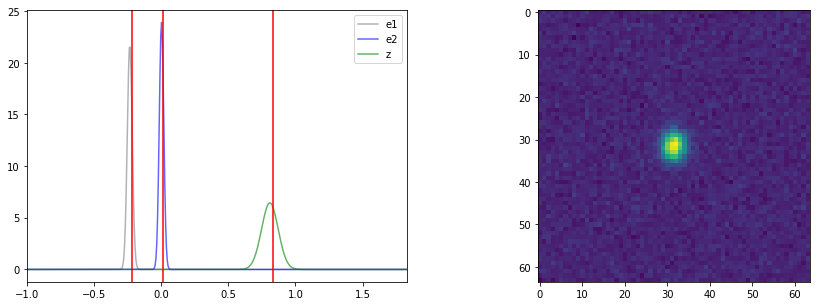

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.linspace(-1,5, 1000)


axes[0].plot(x, (1/(stddevs_e1[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[0,image_nb])/(2*stddevs_e1[0,image_nb]**2))), color = 'grey', alpha = 0.6, label = 'e1')
# mean_means = np.mean(means_e1[:,image_nb])
# mean_stddevs = np.mean(stddevs_e1[:,image_nb])
# axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'black', alpha = 1)    
axes[0].axvline(test_labels[image_nb,0], color = 'r')

axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.6, label= 'e2')
# mean_means = np.mean(means_e2[:,image_nb])
# mean_stddevs = np.mean(stddevs_e2[:,image_nb])
# axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'black', alpha = 1)    
axes[0].axvline(test_labels[image_nb,1], color = 'r')


axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.6, label= 'z')
#mean_means = np.mean(means_z[:,image_nb])
#mean_stddevs = np.mean(stddevs_z[:,image_nb])
#axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'black', alpha = 1)    
axes[0].axvline(test_labels[image_nb,2], color = 'r')
axes[0].set_xlim(-1,test_labels[image_nb,2]+1)

axes[1].imshow(test_data[image_nb,:,:,2])
axes[0].legend()

# Model full probabilistic

Note: for the model to work and train it needs to be train with TF1 (for the K-tied - https://arxiv.org/pdf/2002.02655.pdf - distribution to be used).
    
Consequently some changes are done below to use it with TF1.

## Model architecture

In [59]:
reload(model)

<module 'tools_for_VAE.model' from '../../scripts/tools_for_VAE/tools_for_VAE/model.py'>

In [134]:
net_prob = model.create_model_full_prob_2(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

In [135]:
net_prob.summary()

Model: "model_7"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_8 (InputLayer)         [(None, 64, 64, 6)]       0         
_________________________________________________________________
batch_normalization_7 (Batch (None, 64, 64, 6)         24        
_________________________________________________________________
conv2d_flipout_38 (Conv2DFli (None, 64, 64, 32)        3488      
_________________________________________________________________
p_re_lu_69 (PReLU)           (None, 64, 64, 32)        131072    
_________________________________________________________________
conv2d_flipout_39 (Conv2DFli (None, 32, 32, 32)        18464     
_________________________________________________________________
p_re_lu_70 (PReLU)           (None, 32, 32, 32)        32768     
_________________________________________________________________
conv2d_flipout_40 (Conv2DFli (None, 32, 32, 64)        3692

In [137]:
loading_path = '/sps/lsst/users/barcelin/TFP/weights/test_3_2/loss/'

latest = tf.train.latest_checkpoint(loading_path)
net_prob.load_weights(latest)

## Test

In [81]:
n = 10

In [82]:
test_data = np.zeros((n*batch_size, 64, 64, 6))
test_labels = np.zeros((n*batch_size, 3))

for i in range (n):
    test = test_generator.__getitem__(2)
    test_data[i*batch_size: (i+1)*batch_size] = test[0]
    test_labels[i*batch_size: (i+1)*batch_size] = test[1]

In [83]:
test_data.shape

(1000, 64, 64, 6)

Small changes because TF1 for training of Bayesian Deep Neural nets

In [84]:
out = net(tf.cast(test_data, tf.float32))

In [85]:
# Compute ellipticities in [0,1], inverse function of the one in the generator
out_mean = np.zeros((n*batch_size,3))

out_mean[:,0] = K.get_value(out.mean())[:,0]# out.mean().numpy()[:,0]#np.log(out.mean().numpy()[:,0]/2)
out_mean[:,1] = K.get_value(out.mean())[:,1]#np.log(out.mean().numpy()[:,1]/2)
out_mean[:,2] = K.get_value(out.mean())[:,2]
                    
                    
out_stddev = np.zeros((n*batch_size,3))

out_stddev[:,0] = K.get_value(out.stddev())[:,0]#np.log(out.stddev().numpy()[:,0]/2)
out_stddev[:,1] = K.get_value(out.stddev())[:,1]#np.log(out.stddev().numpy()[:,1]/2)
out_stddev[:,2] = K.get_value(out.stddev())[:,2]

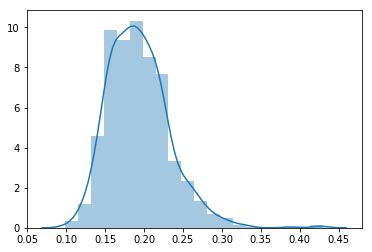

In [86]:
sns.distplot(out_stddev[:,0], bins = 20)

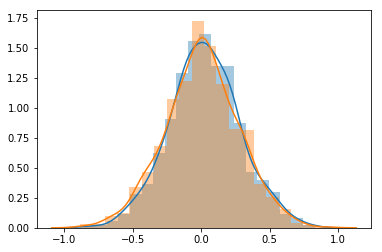

In [87]:
sns.distplot(out_mean[:,0], bins = 20)
sns.distplot(test_labels[:, 0], bins = 20)

### One sampling for 1000 images (ten batch)

Text(0.5, 1.0, '$z$')

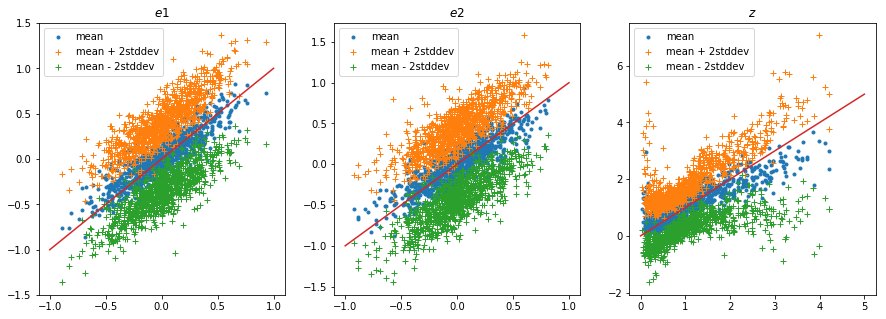

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(test_labels[:, 0], out_mean[:,0], '.', label = 'mean')
axes[0].plot(test_labels[:, 0], out_mean[:,0]+ 2*out_stddev[:,0], '+', label = 'mean + 2stddev')
axes[0].plot(test_labels[:, 0], out_mean[:,0]- 2*out_stddev[:,0], '+', label = 'mean - 2stddev')
x = np.linspace(-1,1)
axes[0].plot(x, x)
axes[0].legend()
#axes[0].set_ylim(-0.5,6.5)
axes[0].set_title('$e1$')

axes[1].plot(test_labels[:, 1], out_mean[:,1], '.', label = 'mean')
axes[1].plot(test_labels[:, 1], out_mean[:,1]+ 2*out_stddev[:,1], '+', label = 'mean + 2stddev')
axes[1].plot(test_labels[:, 1], out_mean[:,1]- 2*out_stddev[:,1], '+', label = 'mean - 2stddev')
x = np.linspace(-1,1)
axes[1].plot(x, x)
axes[1].legend()
#axes[1].set_ylim(-0.5,6.5)
axes[1].set_title('$e2$')

axes[2].plot(test_labels[:,2], out_mean[:,2], '.', label = 'mean')
axes[2].plot(test_labels[:,2], out_mean[:,2]+ 2*out_stddev[:,2], '+', label = 'mean + 2stddev')
axes[2].plot(test_labels[:,2], out_mean[:,2]- 2*out_stddev[:,2], '+', label = 'mean - 2stddev')
x = np.linspace(0,5)
axes[2].plot(x, x)
axes[2].legend()
#axes[2].set_ylim(-1,5.5)
axes[2].set_title('$z$')

### N samplings for 100 images (one batch)

In [93]:
N = 10
means_e1 = np.zeros((N,100))
stddevs_e1 = np.zeros((N,100))
means_e2 = np.zeros((N,100))
stddevs_e2 = np.zeros((N,100))
means_z = np.zeros((N,100))
stddevs_z = np.zeros((N,100))

outs = np.zeros((N,100))
for i in range (N):
    print(i)
    out = net(tf.cast(test_data[:100], tf.float32))
    outs[i] = K.get_value(out[:,0])#.numpy()
    means_e1[i] = K.get_value(out.mean())[:,0]#out.mean().numpy()
    stddevs_e1[i] = K.get_value(out.stddev())[:,0]
    means_e2[i] = K.get_value(out.mean())[:,1]
    stddevs_e2[i] = K.get_value(out.stddev())[:,1]
    means_z[i] = K.get_value(out.mean())[:,2]
    stddevs_z[i] = K.get_value(out.stddev())[:,2]

0
1
2
3
4
5
6
7
8
9


#### 1 sampling : distribution of e1, e2 and z

In [114]:
image_nb = 0

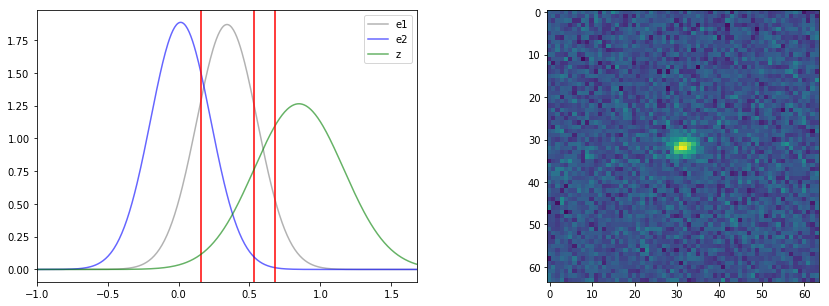

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.linspace(-1,5, 1000)


axes[0].plot(x, (1/(stddevs_e1[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[0,image_nb])/(2*stddevs_e1[0,image_nb]**2))), color = 'grey', alpha = 0.6, label = 'e1')
axes[0].axvline(test_labels[image_nb,0], color = 'r')

axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.6, label= 'e2')
axes[0].axvline(test_labels[image_nb,1], color = 'r')


axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.6, label= 'z')
axes[0].axvline(test_labels[image_nb,2], color = 'r')
axes[0].set_xlim(-1,test_labels[image_nb,2]+1)

axes[1].imshow(test_data[image_nb,:,:,2])
axes[0].legend()

#### 10 sampling : distribution of e1, e2 and z

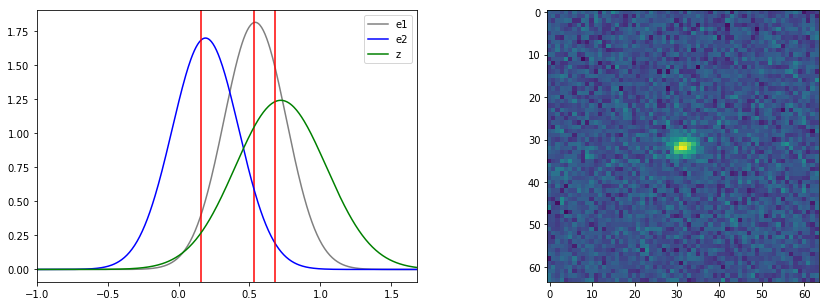

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.linspace(-1,5, 1000)

#for i in range (len(means_e1)):
#    axes[0].plot(x, (1/(stddevs_e1[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[i,image_nb])/(2*stddevs_e1[i,image_nb]**2))), color = 'grey', alpha = 0.3)
#    if i == len(means_e1)-1 : 
#        axes[0].plot(x, (1/(stddevs_e1[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[i,image_nb])/(2*stddevs_e1[i,image_nb]**2))), color = 'grey', alpha = 0.3 , label = 'e1')
mean_means = np.mean(means_e1[:,image_nb])
mean_stddevs = np.mean(stddevs_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'grey', alpha = 1, label = 'e1')    
axes[0].axvline(test_labels[image_nb,0], color = 'r')

#for i in range (len(means_e1)):
#    axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.3)
#    if i == len(means_e1)-1:
#        axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.3, label= 'e2')
mean_means = np.mean(means_e2[:,image_nb])
mean_stddevs = np.mean(stddevs_e2[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'b', alpha = 1, label = 'e2')    
axes[0].axvline(test_labels[image_nb,1], color = 'r')

#for i in range (len(means_e1)):
#    axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.3)
#    if i == len(means_e1)-1:
#        axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.3, label = 'z')
mean_means = np.mean(means_z[:,image_nb])
mean_stddevs = np.mean(stddevs_z[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label = 'z')    
axes[0].axvline(test_labels[image_nb,2], color = 'r')
axes[0].set_xlim(-1,test_labels[image_nb,2]+1)

axes[1].imshow(test_data[image_nb,:,:,2])
axes[0].legend()

### Other example

In [111]:
image_nb = 1

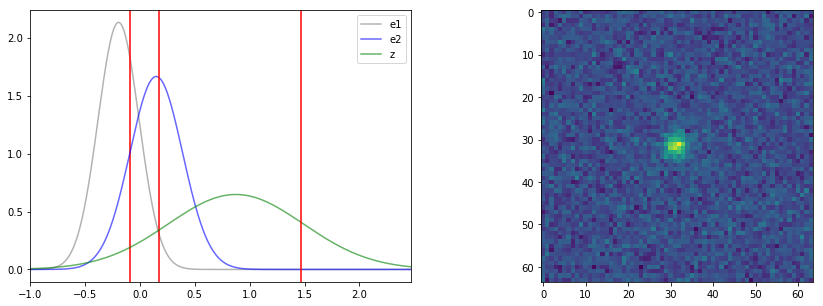

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.linspace(-1,5, 1000)


axes[0].plot(x, (1/(stddevs_e1[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[0,image_nb])/(2*stddevs_e1[0,image_nb]**2))), color = 'grey', alpha = 0.6, label = 'e1')
axes[0].axvline(test_labels[image_nb,0], color = 'r')

axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.6, label= 'e2')
axes[0].axvline(test_labels[image_nb,1], color = 'r')


axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.6, label= 'z')
axes[0].axvline(test_labels[image_nb,2], color = 'r')
axes[0].set_xlim(-1,test_labels[image_nb,2]+1)

axes[1].imshow(test_data[image_nb,:,:,2])
axes[0].legend()

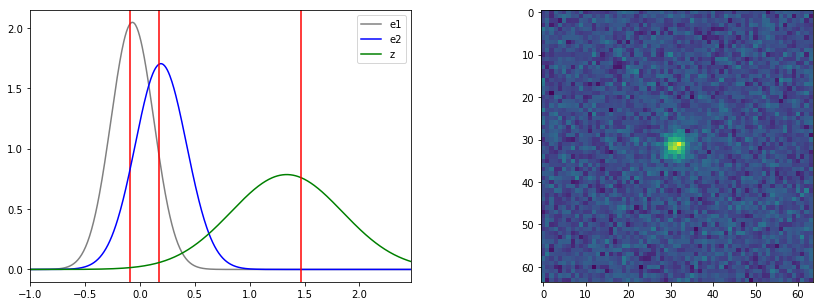

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.linspace(-1,5, 1000)

#for i in range (len(means_e1)):
#    axes[0].plot(x, (1/(stddevs_e1[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[i,image_nb])/(2*stddevs_e1[i,image_nb]**2))), color = 'grey', alpha = 0.3)
#    if i == len(means_e1)-1 : 
#        axes[0].plot(x, (1/(stddevs_e1[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[i,image_nb])/(2*stddevs_e1[i,image_nb]**2))), color = 'grey', alpha = 0.3 , label = 'e1')
mean_means = np.mean(means_e1[:,image_nb])
mean_stddevs = np.mean(stddevs_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'grey', alpha = 1, label = 'e1')    
axes[0].axvline(test_labels[image_nb,0], color = 'r')

#for i in range (len(means_e1)):
#    axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.3)
#    if i == len(means_e1)-1:
#        axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.3, label= 'e2')
mean_means = np.mean(means_e2[:,image_nb])
mean_stddevs = np.mean(stddevs_e2[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'b', alpha = 1, label = 'e2')    
axes[0].axvline(test_labels[image_nb,1], color = 'r')

#for i in range (len(means_e1)):
#    axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.3)
#    if i == len(means_e1)-1:
#        axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.3, label = 'z')
mean_means = np.mean(means_z[:,image_nb])
mean_stddevs = np.mean(stddevs_z[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label = 'z')    
axes[0].axvline(test_labels[image_nb,2], color = 'r')
axes[0].set_xlim(-1,test_labels[image_nb,2]+1)

axes[1].imshow(test_data[image_nb,:,:,2])
axes[0].legend()

# Comparison of with/without latent space

## One sampling for 1000 images (ten batch)

In [127]:
n = 10

In [128]:
test_data = np.zeros((n*batch_size, 64, 64, 6))
test_labels = np.zeros((n*batch_size, 3))

for i in range (n):
    test = test_generator.__getitem__(2)
    test_data[i*batch_size: (i+1)*batch_size] = test[0]
    test_labels[i*batch_size: (i+1)*batch_size] = test[1]

test_data.shape

(1000, 64, 64, 6)

In [138]:
out_with = net(tf.cast(test_data, tf.float32))
out_without = net_wo_ls(tf.cast(test_data, tf.float32))
out_prob = net_prob(tf.cast(test_data, tf.float32))

E1

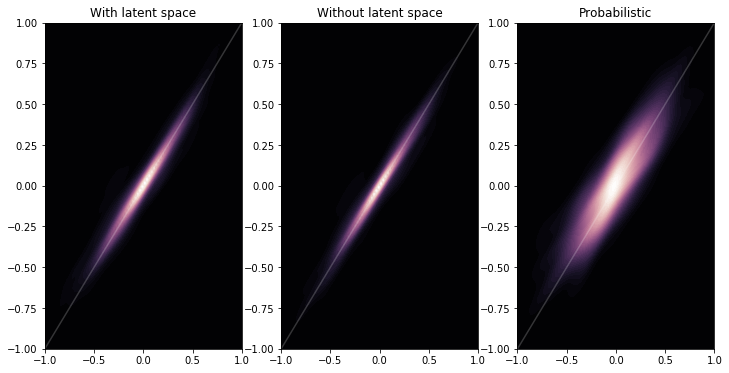

In [140]:
f, ax = plt.subplots(1,3,figsize=(12, 6))
cmap = sns.cubehelix_palette(as_cmap=True, dark=0, light=1, reverse=True)
sns.kdeplot(test_labels[:, 0], K.get_value(out_with.mean())[:,0], cmap=cmap, n_levels=60, shade=True, ax = ax[0])
ax[0].set_title('With latent space')
x = np.linspace(-10,10,1000)
ax[0].set_xlim(-1,1)
ax[0].set_ylim(-1,1)
ax[0].plot(x,x, color = 'white', alpha = 0.2)

sns.kdeplot(test_labels[:, 0], K.get_value(out_without.mean())[:,0], cmap=cmap, n_levels=60, shade=True, ax = ax[1])
ax[1].set_title('Without latent space')
x = np.linspace(-10,10,1000)
ax[1].set_xlim(-1,1)
ax[1].set_ylim(-1,1)
ax[1].plot(x,x, color = 'white', alpha = 0.2)

sns.kdeplot(test_labels[:, 0], K.get_value(out_prob.mean())[:,0], cmap=cmap, n_levels=60, shade=True, ax = ax[2])
ax[2].set_title('Probabilistic')
x = np.linspace(-10,10,1000)
ax[2].set_xlim(-1,1)
ax[2].set_ylim(-1,1)
ax[2].plot(x,x, color = 'white', alpha = 0.2)

E2

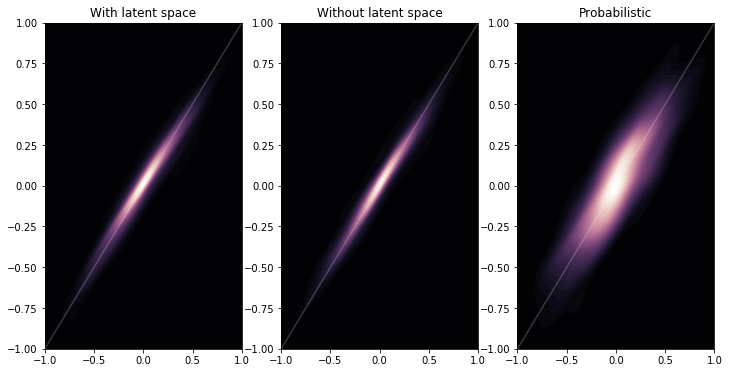

In [141]:
f, ax = plt.subplots(1,3,figsize=(12, 6))
cmap = sns.cubehelix_palette(as_cmap=True, dark=0, light=1, reverse=True)
sns.kdeplot(test_labels[:, 1], K.get_value(out_with.mean())[:,1], cmap=cmap, n_levels=60, shade=True, ax = ax[0])
ax[0].set_title('With latent space')
x = np.linspace(-10,10,1000)
ax[0].set_xlim(-1,1)
ax[0].set_ylim(-1,1)
ax[0].plot(x,x, color = 'white', alpha = 0.2)
sns.kdeplot(test_labels[:, 1], K.get_value(out_without.mean())[:,1], cmap=cmap, n_levels=60, shade=True, ax = ax[1])
ax[1].set_title('Without latent space')
x = np.linspace(-10,10,1000)
ax[1].set_xlim(-1,1)
ax[1].set_ylim(-1,1)
ax[1].plot(x,x, color = 'white', alpha = 0.2)

sns.kdeplot(test_labels[:, 1], K.get_value(out_prob.mean())[:,1], cmap=cmap, n_levels=60, shade=True, ax = ax[2])
ax[2].set_title('Probabilistic')
x = np.linspace(-10,10,1000)
ax[2].set_xlim(-1,1)
ax[2].set_ylim(-1,1)
ax[2].plot(x,x, color = 'white', alpha = 0.2)

Redshift

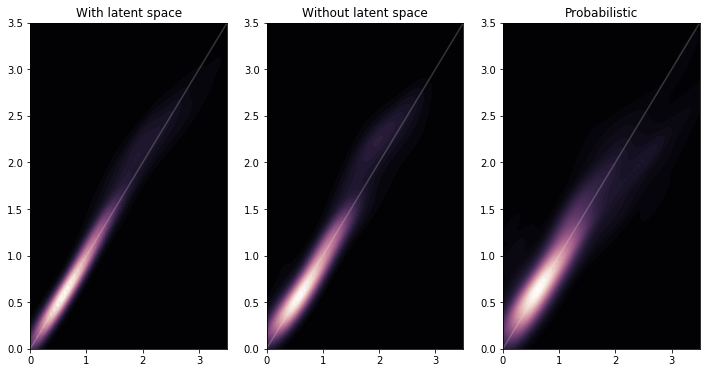

In [143]:
f, ax = plt.subplots(1,3,figsize=(12, 6))
cmap = sns.cubehelix_palette(as_cmap=True, dark=0, light=1, reverse=True)
sns.kdeplot(test_labels[:, 2], K.get_value(out_with.mean())[:,2], cmap=cmap, n_levels=60, shade=True, ax = ax[0])
ax[0].set_title('With latent space')
x = np.linspace(-10,10,1000)
ax[0].set_xlim(0,3.5)
ax[0].set_ylim(0,3.5)
ax[0].plot(x,x, color = 'white', alpha = 0.2)
sns.kdeplot(test_labels[:, 2], K.get_value(out_without.mean())[:,2], cmap=cmap, n_levels=60, shade=True, ax = ax[1])
ax[1].set_title('Without latent space')
x = np.linspace(-10,10,1000)
ax[1].set_xlim(0,3.5)
ax[1].set_ylim(0,3.5)
ax[1].plot(x,x, color = 'white', alpha = 0.2)

sns.kdeplot(test_labels[:, 2], K.get_value(out_prob.mean())[:,2], cmap=cmap, n_levels=60, shade=True, ax = ax[2])
ax[2].set_title('Probabilistic')
x = np.linspace(-10,10,1000)
ax[2].set_xlim(0,3.5)
ax[2].set_ylim(0,3.5)
ax[2].plot(x,x, color = 'white', alpha = 0.2)

### N samplings for 100 images (one batch)

In [ ]:
N = 10
means_with_e1 = np.zeros((N,100))
stddevs_with_e1 = np.zeros((N,100))
means_with_e2 = np.zeros((N,100))
stddevs_with_e2 = np.zeros((N,100))
means_with_z = np.zeros((N,100))
stddevs_with_z = np.zeros((N,100))

means_without_e1 = np.zeros((1,100))
stddevs_without_e1 = np.zeros((1,100))
means_without_e2 = np.zeros((1,100))
stddevs_without_e2 = np.zeros((1,100))
means_without_z = np.zeros((1,100))
stddevs_without_z = np.zeros((1,100))

means_prob_e1 = np.zeros((N,100))
stddevs_prob_e1 = np.zeros((N,100))
means_prob_e2 = np.zeros((N,100))
stddevs_prob_e2 = np.zeros((N,100))
means_prob_z = np.zeros((N,100))
stddevs_prob_z = np.zeros((N,100))

outs_with = np.zeros((N,100))
outs_prob = np.zeros((N,100))
for i in range (N):
    print(i)
    out_with = net(tf.cast(test_data[:100], tf.float32))
    out_prob = net_prob(tf.cast(test_data[:100], tf.float32))

    outs_with[i] = K.get_value(out_with[:,0])
    means_with_e1[i] = K.get_value(out_with.mean())[:,0]
    stddevs_with_e1[i] = K.get_value(out_with.stddev())[:,0]
    means_with_e2[i] = K.get_value(out_with.mean())[:,1]
    stddevs_with_e2[i] = K.get_value(out_with.stddev())[:,1]
    means_with_z[i] = K.get_value(out_with.mean())[:,2]
    stddevs_with_z[i] = K.get_value(out_with.stddev())[:,2]

    outs_prob[i] = K.get_value(out_prob[:,0])
    means_prob_e1[i] = K.get_value(out_prob.mean())[:,0]
    stddevs_prob_e1[i] = K.get_value(out_prob.stddev())[:,0]
    means_prob_e2[i] = K.get_value(out_prob.mean())[:,1]
    stddevs_prob_e2[i] = K.get_value(out_prob.stddev())[:,1]
    means_prob_z[i] = K.get_value(out_prob.mean())[:,2]
    stddevs_prob_z[i] = K.get_value(out_prob.stddev())[:,2]

In [147]:
                                                   
#out_without = net_wo_ls(test_data[:100])
out_without = net_wo_ls(tf.cast(test_data[:100], tf.float32))
means_without_e1[0] = K.get_value(out_without.mean())[:,0]
stddevs_without_e1[0] = K.get_value(out_without.stddev())[:,0]
means_without_e2[0] = K.get_value(out_without.mean())[:,1]
stddevs_without_e2[0] = K.get_value(out_without.stddev())[:,1]
means_without_z[0] = K.get_value(out_without.mean())[:,2]
stddevs_without_z[0] = K.get_value(out_without.stddev())[:,2]

Distribution after 10 samplings

e1: -0.3163630962371826 e0: 0.2521123290061951 redshift: 0.5296000242233276


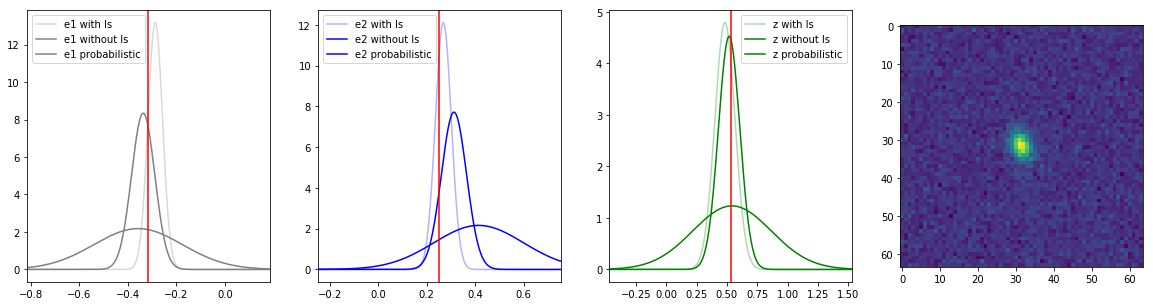

In [156]:
image_nb = 0

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
x = np.linspace(-1,5, 1000)

# E1
axes[0].plot(x, (1/(stddevs_without_e1[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_without_e1[0,image_nb])/(2*stddevs_without_e1[0,image_nb]**2))), color = 'grey', alpha = 0.3, label = 'e1 with ls')

mean_means = np.mean(means_with_e1[:,image_nb])
mean_stddevs = np.mean(stddevs_with_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'grey', alpha = 1, label = 'e1 without ls')    

mean_means_prob = np.mean(means_prob_e1[:,image_nb])
mean_stddevs_prob = np.mean(stddevs_prob_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'grey', alpha = 1, label = 'e1 probabilistic')    

axes[0].axvline(test_labels[image_nb,0], color = 'r')

# E2
axes[1].plot(x, (1/(stddevs_without_e2[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_without_e2[0,image_nb])/(2*stddevs_without_e2[0,image_nb]**2))), color = 'b', alpha = 0.3, label= 'e2 with ls')

mean_means = np.mean(means_with_e2[:,image_nb])
mean_stddevs = np.mean(stddevs_with_e2[:,image_nb])
axes[1].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'b', alpha = 1, label = 'e2 without ls')    

mean_means_prob = np.mean(means_prob_e2[:,image_nb])
mean_stddevs_prob = np.mean(stddevs_prob_e2[:,image_nb])
axes[1].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'b', alpha = 1, label = 'e2 probabilistic')    

axes[1].axvline(test_labels[image_nb,1], color = 'r')

# Redshift
axes[2].plot(x, (1/(stddevs_without_z[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_without_z[0,image_nb])/(2*stddevs_without_z[0,image_nb]**2))), color = 'green', alpha = 0.3, label= 'z with ls')

mean_means = np.mean(means_with_z[:,image_nb])
mean_stddevs = np.mean(stddevs_with_z[:,image_nb])
axes[2].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label= 'z without ls')    

mean_means_prob = np.mean(means_prob_z[:,image_nb])
mean_stddevs_prob = np.mean(stddevs_prob_z[:,image_nb])
axes[2].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'green', alpha = 1, label = 'z probabilistic')    

axes[2].axvline(test_labels[image_nb,2], color = 'r')

# Limit of graphs
axes[0].set_xlim(test_labels[image_nb,0]-0.5,test_labels[image_nb,0]+0.5)
axes[1].set_xlim(test_labels[image_nb,1]-0.5,test_labels[image_nb,1]+0.5)
axes[2].set_xlim(test_labels[image_nb,2]-1,test_labels[image_nb,2]+1)

axes[3].imshow(test_data[image_nb,:,:,2])
axes[0].legend()
axes[1].legend()
axes[2].legend()

print('e1: '+str(test_labels[image_nb,0]), 'e0: '+str(test_labels[image_nb,1]),'redshift: ' +str(test_labels[image_nb,2]))

e1: -0.3170430362224579 e0: 0.1730670928955078 redshift: 1.2419999837875366


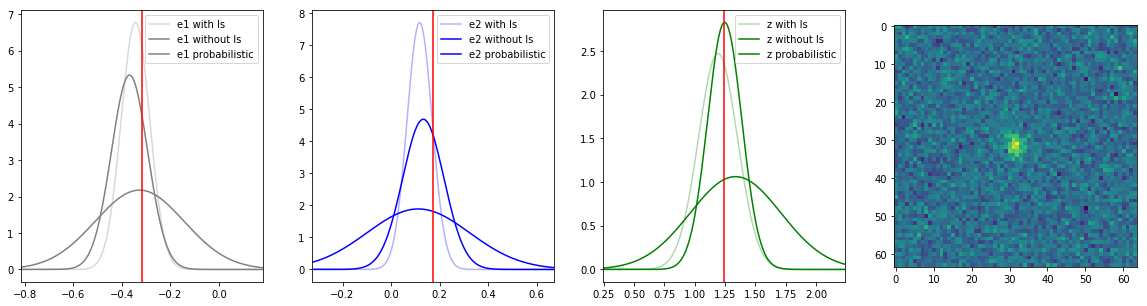

In [157]:
image_nb = 1

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
x = np.linspace(-1,5, 1000)

# E1
axes[0].plot(x, (1/(stddevs_without_e1[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_without_e1[0,image_nb])/(2*stddevs_without_e1[0,image_nb]**2))), color = 'grey', alpha = 0.3, label = 'e1 with ls')

mean_means = np.mean(means_with_e1[:,image_nb])
mean_stddevs = np.mean(stddevs_with_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'grey', alpha = 1, label = 'e1 without ls')    

mean_means_prob = np.mean(means_prob_e1[:,image_nb])
mean_stddevs_prob = np.mean(stddevs_prob_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'grey', alpha = 1, label = 'e1 probabilistic')    

axes[0].axvline(test_labels[image_nb,0], color = 'r')

# E2
axes[1].plot(x, (1/(stddevs_without_e2[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_without_e2[0,image_nb])/(2*stddevs_without_e2[0,image_nb]**2))), color = 'b', alpha = 0.3, label= 'e2 with ls')

mean_means = np.mean(means_with_e2[:,image_nb])
mean_stddevs = np.mean(stddevs_with_e2[:,image_nb])
axes[1].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'b', alpha = 1, label = 'e2 without ls')    

mean_means_prob = np.mean(means_prob_e2[:,image_nb])
mean_stddevs_prob = np.mean(stddevs_prob_e2[:,image_nb])
axes[1].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'b', alpha = 1, label = 'e2 probabilistic')    

axes[1].axvline(test_labels[image_nb,1], color = 'r')

# Redshift
axes[2].plot(x, (1/(stddevs_without_z[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_without_z[0,image_nb])/(2*stddevs_without_z[0,image_nb]**2))), color = 'green', alpha = 0.3, label= 'z with ls')

mean_means = np.mean(means_with_z[:,image_nb])
mean_stddevs = np.mean(stddevs_with_z[:,image_nb])
axes[2].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label= 'z without ls')    

mean_means_prob = np.mean(means_prob_z[:,image_nb])
mean_stddevs_prob = np.mean(stddevs_prob_z[:,image_nb])
axes[2].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'green', alpha = 1, label = 'z probabilistic')    

axes[2].axvline(test_labels[image_nb,2], color = 'r')

# Limit of graphs
axes[0].set_xlim(test_labels[image_nb,0]-0.5,test_labels[image_nb,0]+0.5)
axes[1].set_xlim(test_labels[image_nb,1]-0.5,test_labels[image_nb,1]+0.5)
axes[2].set_xlim(test_labels[image_nb,2]-1,test_labels[image_nb,2]+1)

axes[3].imshow(test_data[image_nb,:,:,2])
axes[0].legend()
axes[1].legend()
axes[2].legend()

print('e1: '+str(test_labels[image_nb,0]), 'e0: '+str(test_labels[image_nb,1]),'redshift: ' +str(test_labels[image_nb,2]))

e1: -0.213632807135582 e0: -0.4391777217388153 redshift: 1.5236999988555908


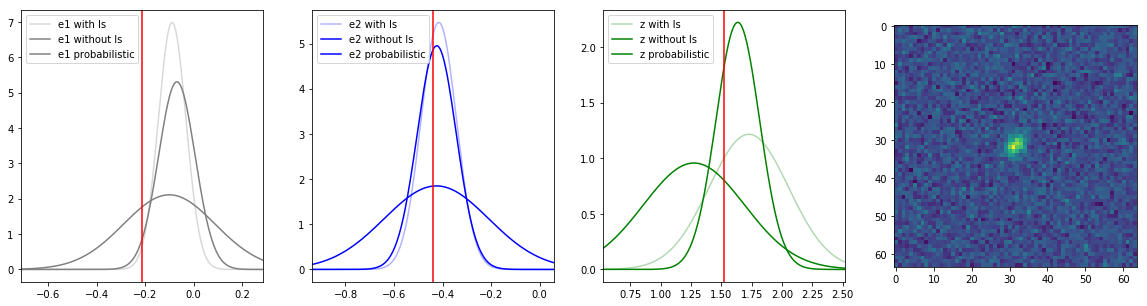

In [158]:
image_nb = 2

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
x = np.linspace(-1,5, 1000)

# E1
axes[0].plot(x, (1/(stddevs_without_e1[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_without_e1[0,image_nb])/(2*stddevs_without_e1[0,image_nb]**2))), color = 'grey', alpha = 0.3, label = 'e1 with ls')

mean_means = np.mean(means_with_e1[:,image_nb])
mean_stddevs = np.mean(stddevs_with_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'grey', alpha = 1, label = 'e1 without ls')    

mean_means_prob = np.mean(means_prob_e1[:,image_nb])
mean_stddevs_prob = np.mean(stddevs_prob_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'grey', alpha = 1, label = 'e1 probabilistic')    

axes[0].axvline(test_labels[image_nb,0], color = 'r')

# E2
axes[1].plot(x, (1/(stddevs_without_e2[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_without_e2[0,image_nb])/(2*stddevs_without_e2[0,image_nb]**2))), color = 'b', alpha = 0.3, label= 'e2 with ls')

mean_means = np.mean(means_with_e2[:,image_nb])
mean_stddevs = np.mean(stddevs_with_e2[:,image_nb])
axes[1].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'b', alpha = 1, label = 'e2 without ls')    

mean_means_prob = np.mean(means_prob_e2[:,image_nb])
mean_stddevs_prob = np.mean(stddevs_prob_e2[:,image_nb])
axes[1].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'b', alpha = 1, label = 'e2 probabilistic')    

axes[1].axvline(test_labels[image_nb,1], color = 'r')

# Redshift
axes[2].plot(x, (1/(stddevs_without_z[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_without_z[0,image_nb])/(2*stddevs_without_z[0,image_nb]**2))), color = 'green', alpha = 0.3, label= 'z with ls')

mean_means = np.mean(means_with_z[:,image_nb])
mean_stddevs = np.mean(stddevs_with_z[:,image_nb])
axes[2].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label= 'z without ls')    

mean_means_prob = np.mean(means_prob_z[:,image_nb])
mean_stddevs_prob = np.mean(stddevs_prob_z[:,image_nb])
axes[2].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'green', alpha = 1, label = 'z probabilistic')    

axes[2].axvline(test_labels[image_nb,2], color = 'r')

# Limit of graphs
axes[0].set_xlim(test_labels[image_nb,0]-0.5,test_labels[image_nb,0]+0.5)
axes[1].set_xlim(test_labels[image_nb,1]-0.5,test_labels[image_nb,1]+0.5)
axes[2].set_xlim(test_labels[image_nb,2]-1,test_labels[image_nb,2]+1)

axes[3].imshow(test_data[image_nb,:,:,2])
axes[0].legend()
axes[1].legend()
axes[2].legend()

print('e1: '+str(test_labels[image_nb,0]), 'e0: '+str(test_labels[image_nb,1]),'redshift: ' +str(test_labels[image_nb,2]))